# SemRel Dataset — Preprocessing Pipeline
**COS 760 Group Project**  
This notebook preprocesses the SemRel dataset for **Afrikaans**.
It loads `dev` and `test` from HuggingFace, splits `dev` 80/20 into train/val,
cleans all three splits, and saves CSVs for model notebooks to consume.

## 1. Install & Import Dependencies

In [1]:
!pip install datasets transformers pandas numpy matplotlib seaborn scikit-learn -q

In [2]:
import os
import re
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from datasets import load_dataset

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130

# Set HF token to avoid rate-limit warnings (get one at huggingface.co/settings/tokens)
# os.environ['HF_TOKEN'] = 'hf_your_token_here'

LANGUAGES      = ['afr']
LANGUAGE_NAMES = {'afr': 'Afrikaans'}
# Splits produced by this notebook (train is created by splitting HF dev)
SPLITS         = ['train', 'dev', 'test']
OUTPUT_DIR     = './cleaned_data'
os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_SEED    = 42
TRAIN_RATIO    = 0.80          # 80 % of HF dev → train, 20 % → val/dev

print('Setup complete.')
print(f'Output directory: {OUTPUT_DIR}')


Setup complete.
Output directory: ./cleaned_data


## 2. Load Raw Data from HuggingFace

In [3]:
# HuggingFace only provides 'dev' and 'test' for SemRel2024 Afrikaans.
# We create 'train' by splitting 'dev' 80/20.
HF_SPLITS = ['dev', 'test']

raw_data = {}

for lang in LANGUAGES:
    raw_data[lang] = {}
    hf_frames = {}

    # Load the two available HF splits
    for split in HF_SPLITS:
        try:
            dataset = load_dataset('SemRel/SemRel2024', lang, split=split)
            df = dataset.to_pandas().rename(columns={'label': 'score'})
            hf_frames[split] = df
            print(f'Loaded {LANGUAGE_NAMES[lang]} {split}: {len(df)} rows')
        except Exception as e:
            print(f'Could not load {lang} {split}: {e}')

    # Split HF dev → train (80 %) + dev (20 %)
    if 'dev' in hf_frames:
        train_df, val_df = train_test_split(
            hf_frames['dev'],
            train_size=TRAIN_RATIO,
            random_state=RANDOM_SEED,
            shuffle=True,
        )
        raw_data[lang]['train'] = train_df.reset_index(drop=True)
        raw_data[lang]['dev']   = val_df.reset_index(drop=True)
        print(f'Split dev → train: {len(raw_data[lang]["train"])} rows, '
              f'dev: {len(raw_data[lang]["dev"])} rows')

    if 'test' in hf_frames:
        raw_data[lang]['test'] = hf_frames['test'].reset_index(drop=True)

print('\nDataset loading complete.')


Loaded Afrikaans dev: 375 rows
Loaded Afrikaans test: 375 rows
Split dev → train: 300 rows, dev: 75 rows

Dataset loading complete.


## 3. Schema Inspection

In [4]:
# Show columns and a sample from the train split
if 'afr' in raw_data and 'train' in raw_data['afr']:
    df_sample = raw_data['afr']['train']
    print('Schema for Afrikaans train:')
    print(df_sample.dtypes)
    print()
    display(df_sample.head(5))
else:
    print('Afrikaans train data not available.')


Schema for Afrikaans train:
sentence1     object
sentence2     object
score        float64
dtype: object



,sentence1,sentence2,score
0,Die sand en steen wat n dam moes vorm het net ...,Op hierdie manier kan n paar sinkkuipe langs m...,0.47
1,Vir elke dag van die jaar is daar 'n kort aanh...,Begin elke dag met hierdie aanhaling en dra di...,0.62
2,"Omdat lig nie om n voorwerp kan beweeg nie, vo...",Baie voorwerpe laat wel n hoeveelheid lig deur...,0.84
3,"Die beste manier om n gewrig te laat rus, is o...","Dit is baie doeltreffend, want n groot dosis k...",0.28
4,Neem n afvalstukkie kroonlys en merk waar dit ...,Posisioneer die lys waar die muur en plafon on...,0.59


## 4. Dataset Size Summary

In [5]:
print('Dataset size summary:')
print(f'{"Language":<15} {"Train":<10} {"Dev":<10} {"Test":<10}')
print('-' * 45)
for lang in LANGUAGES:
    sizes = []
    for split in SPLITS:
        n = len(raw_data[lang][split]) if lang in raw_data and split in raw_data[lang] else 'N/A'
        sizes.append(str(n))
    print(f'{LANGUAGE_NAMES[lang]:<15} {sizes[0]:<10} {sizes[1]:<10} {sizes[2]:<10}')


Dataset size summary:
Language        Train      Dev        Test      
---------------------------------------------
Afrikaans       300        75         375       


## 5. Score Distribution (Raw)

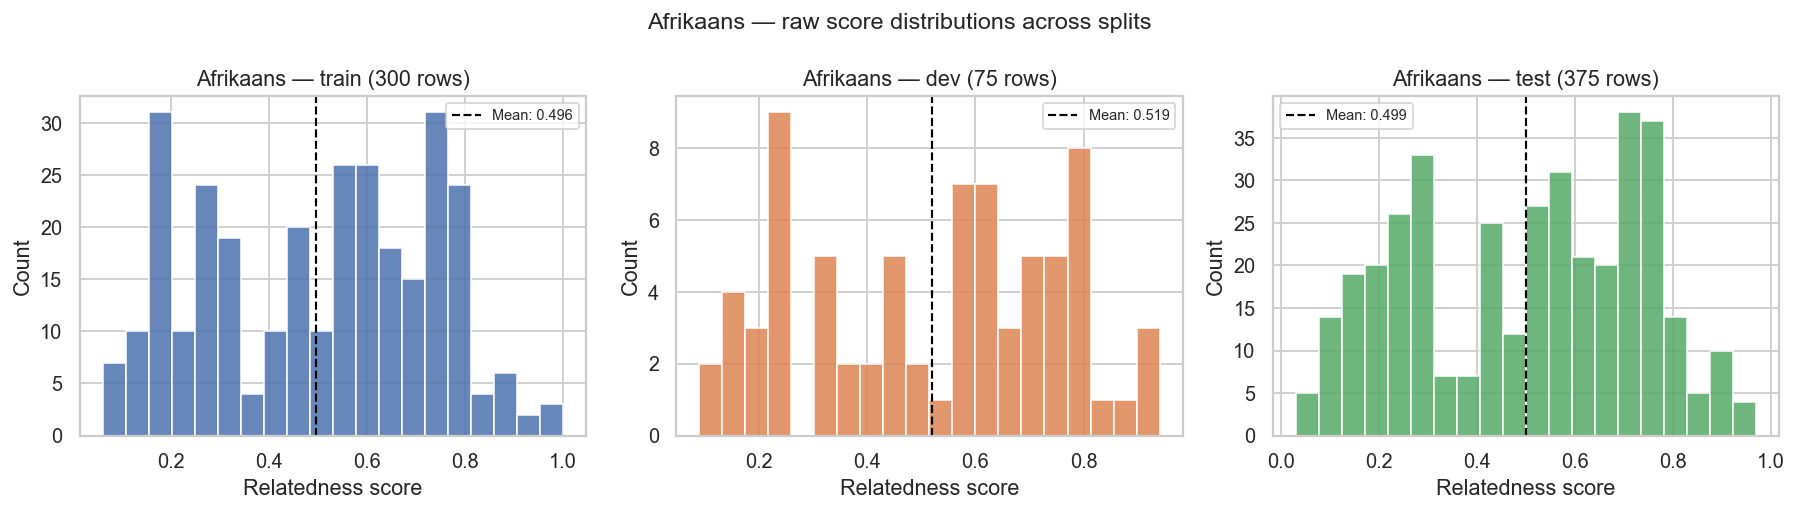

Score distribution plot saved.


In [6]:
split_colors = {'train': '#4C72B0', 'dev': '#DD8452', 'test': '#55A868'}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for j, split in enumerate(SPLITS):
    ax = axes[j]
    if 'afr' in raw_data and split in raw_data['afr']:
        scores = raw_data['afr'][split]['score']
        ax.hist(scores, bins=20, color=split_colors[split], edgecolor='white', alpha=0.85)
        ax.axvline(scores.mean(), color='black', linestyle='--', linewidth=1.2,
                   label=f'Mean: {scores.mean():.3f}')
        ax.legend(fontsize=8)
        ax.set_title(f'Afrikaans — {split} ({len(scores)} rows)')
    else:
        ax.text(0.5, 0.5, 'No data', transform=ax.transAxes,
                ha='center', va='center', color='gray')
        ax.set_title(f'Afrikaans — {split}')
    ax.set_xlabel('Relatedness score')
    ax.set_ylabel('Count')

fig.suptitle('Afrikaans — raw score distributions across splits', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Score distribution plot saved.')


In [7]:
print('Descriptive statistics (raw):')
print(f'{"Split":<8} {"Min":<8} {"Max":<8} {"Mean":<8} {"Std":<8} {"Skew"}')
print('-' * 50)
for split in SPLITS:
    if 'afr' in raw_data and split in raw_data['afr']:
        s = raw_data['afr'][split]['score']
        print(f'{split:<8} {s.min():<8.4f} {s.max():<8.4f} '
              f'{s.mean():<8.4f} {s.std():<8.4f} {s.skew():.4f}')


Descriptive statistics (raw):
Split    Min      Max      Mean     Std      Skew
--------------------------------------------------
train    0.0600   1.0000   0.4962   0.2335   -0.1172
dev      0.0900   0.9400   0.5191   0.2351   -0.1588
test     0.0300   0.9700   0.4993   0.2337   -0.1396


## 6. Define Preprocessing Function

In [8]:
def preprocess_dataframe(df: pd.DataFrame, lang: str, split: str) -> pd.DataFrame:
    """
    Clean a raw SemRel dataframe.

    Steps:
      1. Rename 'label' -> 'score' if needed
      2. Drop rows with missing sentence1 / sentence2 / score
      3. Strip and normalise whitespace in sentences
      4. Remove empty sentences
      5. Cast score to float
      6. Drop duplicate (sentence1, sentence2) pairs
      7. Add lang and split metadata columns
    """
    original_len = len(df)
    df = df.copy()

    # 1. Normalise score column name
    if 'label' in df.columns and 'score' not in df.columns:
        df = df.rename(columns={'label': 'score'})

    # 2. Drop missing values
    df = df.dropna(subset=['sentence1', 'sentence2', 'score'])

    # 3. Strip / normalise whitespace
    df['sentence1'] = df['sentence1'].str.strip().str.replace(r'\s+', ' ', regex=True)
    df['sentence2'] = df['sentence2'].str.strip().str.replace(r'\s+', ' ', regex=True)

    # 4. Remove empty sentences
    df = df[(df['sentence1'].str.len() > 0) & (df['sentence2'].str.len() > 0)]

    # 5. Ensure float score
    df['score'] = df['score'].astype(float)

    # 6. Drop duplicates
    df = df.drop_duplicates(subset=['sentence1', 'sentence2'])

    # 7. Metadata
    df['lang']  = lang
    df['split'] = split

    df = df.reset_index(drop=True)
    removed = original_len - len(df)
    print(f'  [{lang}] {split}: {original_len} → {len(df)} rows  '
          f'({removed} removed)')
    return df


## 7. Run Preprocessing

In [9]:
cleaned_data = {}

print('Preprocessing Afrikaans splits:')
print('-' * 45)

for lang in LANGUAGES:
    cleaned_data[lang] = {}
    for split in SPLITS:
        if lang in raw_data and split in raw_data[lang]:
            try:
                cleaned_data[lang][split] = preprocess_dataframe(
                    raw_data[lang][split], lang, split
                )
            except Exception as e:
                print(f'  Error preprocessing {lang} {split}: {e}')

print('\nPreprocessing complete.')


Preprocessing Afrikaans splits:
---------------------------------------------
  [afr] train: 300 → 300 rows  (0 removed)
  [afr] dev: 75 → 75 rows  (0 removed)
  [afr] test: 375 → 375 rows  (0 removed)

Preprocessing complete.


## 8. Sentence Length Analysis (Cleaned)

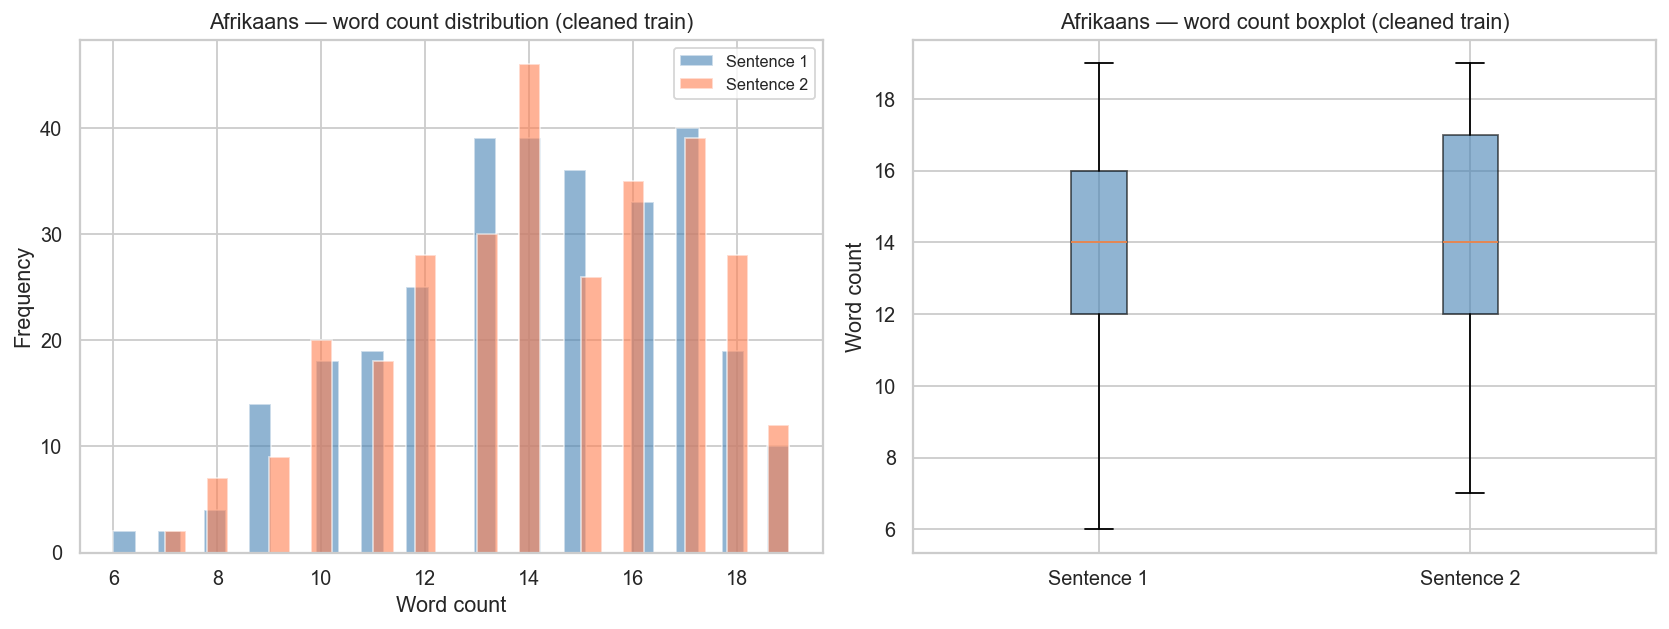

Sentence 1 avg: 14.0 words  |  Sentence 2 avg: 14.2 words
Max S1: 19  |  Max S2: 19


In [10]:
if 'afr' in cleaned_data and 'train' in cleaned_data['afr']:
    df = cleaned_data['afr']['train']
    lengths_s1 = df['sentence1'].apply(lambda x: len(x.split()))
    lengths_s2 = df['sentence2'].apply(lambda x: len(x.split()))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Histogram
    axes[0].hist(lengths_s1, bins=30, alpha=0.6, label='Sentence 1', color='steelblue')
    axes[0].hist(lengths_s2, bins=30, alpha=0.6, label='Sentence 2', color='coral')
    axes[0].set_title('Afrikaans — word count distribution (cleaned train)')
    axes[0].set_xlabel('Word count')
    axes[0].set_ylabel('Frequency')
    axes[0].legend(fontsize=9)

    # Boxplot
    axes[1].boxplot([lengths_s1, lengths_s2], labels=['Sentence 1', 'Sentence 2'],
                    patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[1].set_title('Afrikaans — word count boxplot (cleaned train)')
    axes[1].set_ylabel('Word count')

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/sentence_lengths.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Sentence 1 avg: {lengths_s1.mean():.1f} words  |  '
          f'Sentence 2 avg: {lengths_s2.mean():.1f} words')
    print(f'Max S1: {lengths_s1.max()}  |  Max S2: {lengths_s2.max()}')


## 9. Save Cleaned Data
Saves `afr_train.csv`, `afr_dev.csv`, `afr_test.csv` and a combined CSV.

In [11]:
all_frames = []

for lang in LANGUAGES:
    for split in SPLITS:
        if lang in cleaned_data and split in cleaned_data[lang]:
            df = cleaned_data[lang][split]
            filename = f'{OUTPUT_DIR}/{lang}_{split}.csv'
            df.to_csv(filename, index=False)
            print(f'Saved: {filename}  ({len(df)} rows)')
            all_frames.append(df)

# Combined file
if all_frames:
    combined = pd.concat(all_frames, ignore_index=True)
    combined_path = f'{OUTPUT_DIR}/all_languages_combined.csv'
    combined.to_csv(combined_path, index=False)
    print(f'\nSaved combined: {combined_path}  ({len(combined)} rows total)')


Saved: ./cleaned_data/afr_train.csv  (300 rows)
Saved: ./cleaned_data/afr_dev.csv  (75 rows)
Saved: ./cleaned_data/afr_test.csv  (375 rows)

Saved combined: ./cleaned_data/all_languages_combined.csv  (750 rows total)


## 10. Helper Loaders for Model Notebooks
Copy these functions into any downstream notebook to load the cleaned data.

In [12]:
def load_split(lang: str, split: str, data_dir: str = './cleaned_data') -> pd.DataFrame:
    """
    Load a single language/split CSV.
    Example:
        train_df = load_split('afr', 'train')
    """
    path = os.path.join(data_dir, f'{lang}_{split}.csv')
    if not os.path.exists(path):
        raise FileNotFoundError(
            f'File not found: {path}\nRun the preprocessing notebook first.'
        )
    return pd.read_csv(path)


def load_all_splits(lang: str = 'afr', data_dir: str = './cleaned_data'):
    """
    Load train, dev, and test splits for a language.
    Returns: (train_df, dev_df, test_df)
    Example:
        train, dev, test = load_all_splits()
    """
    return (
        load_split(lang, 'train', data_dir),
        load_split(lang, 'dev',   data_dir),
        load_split(lang, 'test',  data_dir),
    )


# Quick verification
print('Testing loaders...')
try:
    train, dev, test = load_all_splits()
    print(f'  train: {len(train)} rows')
    print(f'  dev:   {len(dev)} rows')
    print(f'  test:  {len(test)} rows')
    display(train.head(3))
except FileNotFoundError as e:
    print(e)


Testing loaders...
  train: 300 rows
  dev:   75 rows
  test:  375 rows


,sentence1,sentence2,score,lang,split
0,Die sand en steen wat n dam moes vorm het net ...,Op hierdie manier kan n paar sinkkuipe langs m...,0.47,afr,train
1,Vir elke dag van die jaar is daar 'n kort aanh...,Begin elke dag met hierdie aanhaling en dra di...,0.62,afr,train
2,"Omdat lig nie om n voorwerp kan beweeg nie, vo...",Baie voorwerpe laat wel n hoeveelheid lig deur...,0.84,afr,train


## 11. Final Summary

In [13]:
print('=' * 45)
print('PREPROCESSING COMPLETE — FINAL SUMMARY')
print('=' * 45)
print(f'{"Split":<8} {"Rows":<8} {"Score mean":<12} {"Score std"}')
print('-' * 40)

for split in SPLITS:
    if 'afr' in cleaned_data and split in cleaned_data['afr']:
        df = cleaned_data['afr'][split]
        s  = df['score']
        print(f'{split:<8} {len(df):<8} {s.mean():<12.4f} {s.std():.4f}')

print()
print('Cleaned CSVs saved to:', OUTPUT_DIR)
print()
print('Load in your model notebook with:')
print('  train, dev, test = load_all_splits()')


PREPROCESSING COMPLETE — FINAL SUMMARY
Split    Rows     Score mean   Score std
----------------------------------------
train    300      0.4962       0.2335
dev      75       0.5191       0.2351
test     375      0.4993       0.2337

Cleaned CSVs saved to: ./cleaned_data

Load in your model notebook with:
  train, dev, test = load_all_splits()
